# 🚗 Path Planning for Autonomous Driving
**Course**: Introduction to Artificial Intelligence



### Environment Setup

In [1]:
# 1. Clone the repository
!git clone https://github.com/khoadangnguyenn/NeuroDrive-K.git
%cd NeuroDrive-K

# 2. Install dependencies
%pip install -r requirements.txt
# 3. Add current directory to path for module imports
import sys
import os
sys.path.append(os.getcwd())

Cloning into 'NeuroDrive-K'...
remote: Enumerating objects: 256, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 256 (delta 40), reused 21 (delta 21), pack-reused 192 (from 1)
Receiving objects: 100% (256/256), 9.72 MiB | 21.44 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content/NeuroDrive-K


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import Image as DisplayImage, display

# Import our custom modules
from modules.feature_engineering import perform_feature_engineering
from modules.perception_ml import train_perception_models, predict_perception, FEATURES
from modules.bayes import apply_bayesian_update
from modules.rule_based import apply_safety_rules, apply_behavior_rules, set_goal
from modules.knowledge_base import create_grid_map
from modules.path_planner import plan_path_with_fallback
from modules.visualizer import visualize_scenario, create_scenario_gif
from test_analysis import run_test_analysis

# Global Constants
GRID_WIDTH = 120
GRID_HEIGHT = 80
sns.set(style="whitegrid")

## 1. Load Data

Dataset URL: https://www.kaggle.com/datasets/ziya07/entrepreneurial-ability-assessment-dataset
License(s): CC0-1.0
100% 666k/666k [00:00<00:00, 788kB/s]

Archive:  entrepreneurial-ability-assessment-dataset.zip
  inflating: data/autonomous_driving_expanded_dataset.csv  
Dataset loaded: 5000 rows


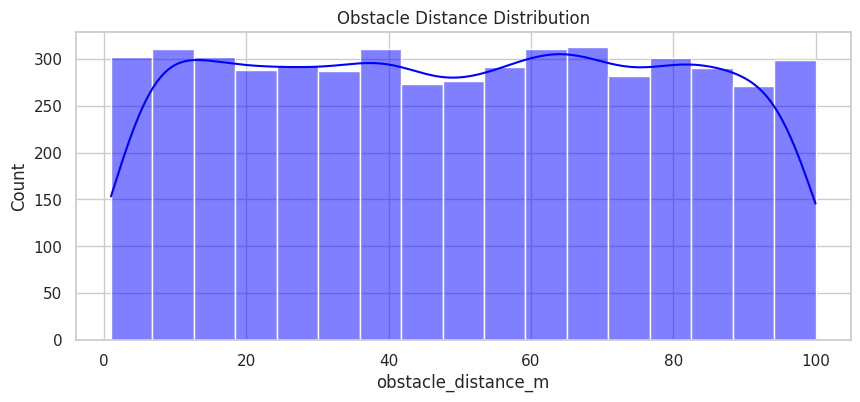

In [3]:
# Download dataset
!kaggle datasets download -d ziya07/entrepreneurial-ability-assessment-dataset
# Extract zip
!unzip -o entrepreneurial-ability-assessment-dataset.zip -d data
data_path = "data/autonomous_driving_expanded_dataset.csv"
df = pd.read_csv(data_path)
print(f"Dataset loaded: {len(df)} rows")

# Basic Analysis
plt.figure(figsize=(10, 4))
sns.histplot(df['obstacle_distance_m'], kde=True, color='blue')
plt.title('Obstacle Distance Distribution')
plt.show()

## 2. Feature Engineer

Performing Feature Engineering...
Performing Feature Engineering (Optimized)...
  → Created 17 engineered features.
  → Features saved to CSV: /content/NeuroDrive-K/features/processed_features.csv
  → Numeric features saved to NPY: /content/NeuroDrive-K/features/processed_features.npy


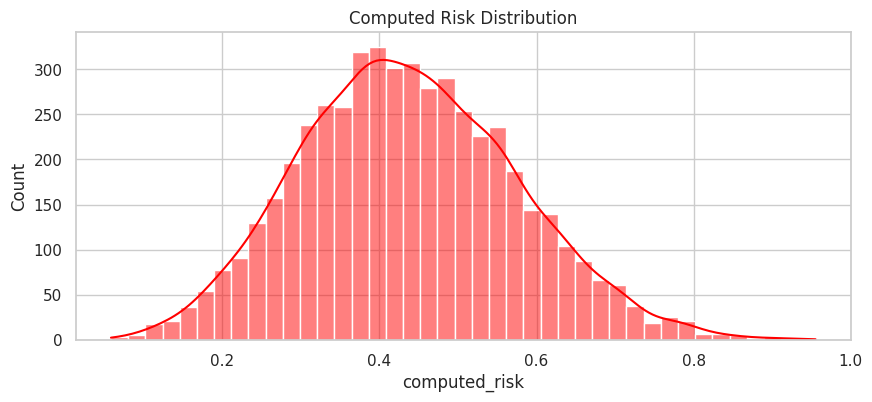

In [4]:
print("Performing Feature Engineering...")
df_feat = perform_feature_engineering(df)

# Feature Visualization
plt.figure(figsize=(10, 4))
sns.histplot(df_feat['computed_risk'], kde=True, color='red')
plt.title('Computed Risk Distribution')
plt.show()

## 3. ML Training

In [5]:
print("Training Perception Models...")
model_nb, model_dt, le_behavior, scaler, model_rf, model_xgb_cls, model_xgb_reg = train_perception_models(df_feat)
print("Training Complete.")

Training Perception Models...
Training Perception Models (Optimized)...
  → Using 33 features
  → StandardScaler fitted

  --- Behavior Prediction (Classification) ---
  → Classes: ['follow', 'lane_change', 'overtake', 'stop', 'yield']

  [1] Naive Bayes Training:
    Accuracy: 0.6790
  [2] RandomForest Ensemble Training:
    Accuracy: 0.7610

  → Using RandomForest for behavior prediction

  [2.1] XGBoost Classification Training:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:19:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    XGBoost Accuracy: 0.7850
    → XGBoost outperformed RandomForest, using XGBoost.

  --- Risk Assessment (Regression) ---

  [3] Decision Tree Regressor Training:
    R² Score: 0.9548

  [3.1] Gradient Boosting Regressor Training:
    R² Score: 0.9917

  [4] XGBoost Regression Training:
    XGBoost R² Score: 0.9946
    → XGBoost outperformed Decision Tree, using XGBoost.

  --- SHAP Explainability ---

  → SHAP computation failed: property 'feature_names_in_' of 'XGBClassifier' object has no setter

  → Models saved to /content/NeuroDrive-K/models
Training Complete.


## 4. Simulation Execution

### 4.1 Perception Inference (ML)

In [6]:
idx = 14
row = df_feat.iloc[idx]

predicted_behavior_ml, risk_score_ml = predict_perception(
    row, model_nb, model_dt, le_behavior, FEATURES,
    scaler=scaler, model_rf=model_rf,
    model_xgb_cls=model_xgb_cls, model_xgb_reg=model_xgb_reg
)
print(f"  > [ML] Predicted: {predicted_behavior_ml} | Score: {risk_score_ml:.4f}")


  > [ML] Predicted: overtake | Score: 0.6742


### 4.2 Bayesian Risk Model

In [7]:
p_base, p_risk = apply_bayesian_update(
    risk_score_ml,
    row['weather_condition'],
    row['road_surface_condition'],
    row['visibility_range_m']
)
print(f"Bayesian Updated Risk: {p_risk:.4f} (Base Environment: {p_base:.4f})")

Bayesian Updated Risk: 0.6308 (Base Environment: 0.5032)


### 4.3 Rule-based System

In [8]:
safety_decision = apply_safety_rules(row)
if safety_decision:
    final_behavior = safety_decision
    print(f"Safety override: {final_behavior}")
else:
    final_behavior = apply_behavior_rules(row)
    print(f"Tactical decision: {final_behavior}")

Safety override: yield


### 4.4 Map Fusion

In [9]:
grid, start = create_grid_map(row, p_risk, final_behavior, grid_width=GRID_WIDTH, grid_height=GRID_HEIGHT)
goal = set_goal(row, final_behavior, start, grid, GRID_WIDTH, GRID_HEIGHT)
print(f"Cost grid generated. Start: {start}, Goal: {goal}")

Cost grid generated. Start: (37, 10), Goal: (23, 110)


### 4.5 Path Planning Algorithm

In [10]:
path, fsm_cmd, used_fallback = plan_path_with_fallback(grid, start, goal, final_behavior)

if path:
    print(f"Path Planning Success! ({len(path)} nodes). Fallback used: {used_fallback}")
else:
    print(f"Path Planning Failed. Action: {fsm_cmd}")

Path Planning Success! (101 nodes). Fallback used: False


## 5. Visualization & Output

Generating Visualization...
  > [SAVED] Visualization at /content/NeuroDrive-K/visualize/plots/scenario_14.png
  > Generating GIF frames for Scenario 14...................................................... [DONE]
  > [SAVED] Animation at /content/NeuroDrive-K/visualize/gifs/scenario_14.gif


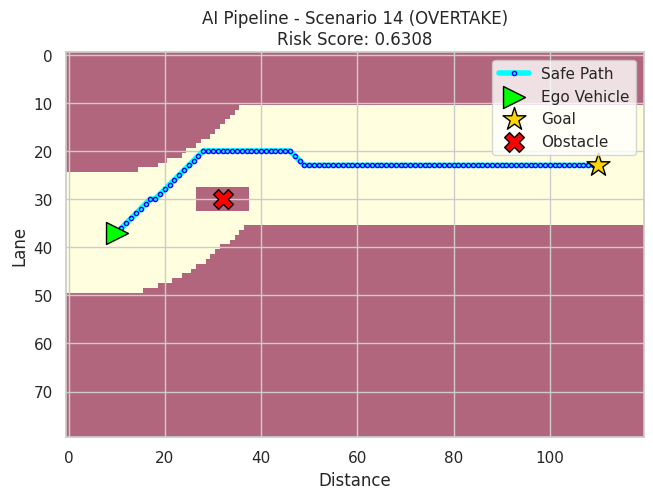

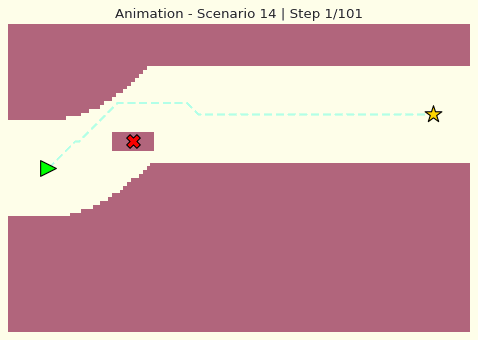

In [11]:
if path or fsm_cmd == "brake":
    print("Generating Visualization...")
    visualize_scenario(grid, path, start, goal, row, p_risk, idx)

    if path:
        create_scenario_gif(grid, path, start, goal, row, p_risk, idx)

    plot_path = f'visualize/plots/scenario_{idx}.png'
    gif_path = f'visualize/gifs/scenario_{idx}.gif'

    if os.path.exists(plot_path):
        display(DisplayImage(filename=plot_path))

    if os.path.exists(gif_path):
        display(DisplayImage(filename=gif_path))

## 6. Test

In [12]:
print(f"[INFO] Starting Comprehensive Results Analysis...")
run_test_analysis()


[INFO] Starting Comprehensive Results Analysis...
  AUTONOMOUS DRIVING - COMPREHENSIVE RESULTS ANALYSIS
Performing Feature Engineering (Optimized)...
  → Created 17 engineered features.
  → Features saved to CSV: /content/NeuroDrive-K/features/processed_features.csv
  → Numeric features saved to NPY: /content/NeuroDrive-K/features/processed_features.npy

[6.1.1] Đánh giá mô hình Behavior Prediction (Classification)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Table 1.1: Kết quả đánh giá Behavior Prediction
| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Random Forest | 76.1% | 71.6% | 76.3% | 68.0% |
| XGBoost | 78.5% | 72.7% | 70.3% | 67.4% |
| Decision Tree | 74.7% | 65.1% | 66.7% | 64.4% |
| Naive Bayes | 67.9% | 58.9% | 66.0% | 53.3% |

[6.1.2] Đánh giá mô hình Risk Prediction (Regression)...

Table 1.2: Kết quả đánh giá Risk Prediction
| Model | R2 Score | MAE | MSE |
|-------|----------|-----|-----|
| XGBoost | 0.9946 | 0.0078 | 0.0001 |
| Gradient Boosting | 0.9917 | 0.0098 | 0.0002 |
| Decision Tree | 0.9548 | 0.0227 | 0.0009 |

[6.2] Hiệu suất thuật toán A*...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(



Table 2: Hiệu suất thuật toán A*
| Scenario | Time(ms) | States | Success Rate |
|----------|----------|--------|--------------|
| Urban Traffic | 131.2 | 7252 | 90% |
| Highway | 72.4 | 6462 | 100% |
| Foggy Weather | 49.2 | 5329 | 100% |

[6.3 & 6.4] Đánh giá an toàn & So sánh kịch bản...

Table 3: So sánh các kịch bản
| Scenario | Collision Rate | ADE | Stability |
|----------|----------------|-----|-----------|
| Normal Weather | 35.3% | 0.26 | Medium |
| Foggy Weather | 39.9% | 0.24 | Medium |

  ANALYSIS COMPLETE
